In [1]:
# 필요한 라이브러리 import
import os
import sys
import random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import glob

# 플롯 설정
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

print("✅ 라이브러리 import 완료")


✅ 라이브러리 import 완료


In [2]:
# 🛠️ 데이터셋 경로 설정
BASE_DIR = "/home/byounggun/ultralytics/swm_total"
WIDE_IMAGES_DIR = os.path.join(BASE_DIR, "images")
NARROW_IMAGES_DIR = os.path.join(BASE_DIR, "narrow_images")
LABELS_DIR = os.path.join(BASE_DIR, "labels")

# 클래스 이름 정의 (28개 클래스)
CLASS_NAMES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie'
]

# 색상 팔레트 (각 클래스별)
COLORS = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', '#800000', '#008000',
    '#000080', '#808000', '#800080', '#008080', '#FFA500', '#FFC0CB', '#A52A2A', '#DDA0DD',
    '#98FB98', '#F0E68C', '#DEB887', '#D2691E', '#FF7F50', '#6495ED', '#DC143C', '#00CED1',
    '#B8860B', '#A9A9A9', '#006400', '#8B008B'
]

print(f"📂 데이터셋 경로:")
print(f"  Wide images: {WIDE_IMAGES_DIR}")
print(f"  Narrow images: {NARROW_IMAGES_DIR}")
print(f"  Labels: {LABELS_DIR}")
print(f"📊 클래스 수: {len(CLASS_NAMES)}")


📂 데이터셋 경로:
  Wide images: /home/byounggun/ultralytics/swm_total/images
  Narrow images: /home/byounggun/ultralytics/swm_total/narrow_images
  Labels: /home/byounggun/ultralytics/swm_total/labels
📊 클래스 수: 28


In [3]:
# 🔧 유틸리티 함수들

def load_yolo_labels(label_path, image_width, image_height):
    """
    YOLO 포맷 라벨 파일을 읽어서 픽셀 좌표로 변환
    
    Args:
        label_path (str): 라벨 파일 경로
        image_width (int): 이미지 너비
        image_height (int): 이미지 높이
    
    Returns:
        list: [(class_id, x1, y1, x2, y2), ...] 형태의 리스트
    """
    if not os.path.exists(label_path):
        return []
    
    boxes = []
    
    with open(label_path, 'r') as f:
        for line in f.readlines():
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            if len(parts) != 5:
                continue
            
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
            
            # YOLO 좌표를 픽셀 좌표로 변환
            x1 = int((x_center - width/2) * image_width)
            y1 = int((y_center - height/2) * image_height)
            x2 = int((x_center + width/2) * image_width)
            y2 = int((y_center + height/2) * image_height)
            
            boxes.append((class_id, x1, y1, x2, y2))
    
    return boxes

def get_image_files():
    """
    데이터셋의 모든 이미지 파일 리스트 가져오기
    
    Returns:
        list: 이미지 파일명 리스트 (확장자 없음)
    """
    wide_files = glob.glob(os.path.join(WIDE_IMAGES_DIR, "*.jpg"))
    image_names = [os.path.splitext(os.path.basename(f))[0] for f in wide_files]
    return sorted(image_names)

def check_files_exist(image_name):
    """
    이미지와 관련 파일들이 존재하는지 확인
    
    Args:
        image_name (str): 이미지 파일명 (확장자 없음)
    
    Returns:
        dict: 각 파일의 존재 여부
    """
    wide_path = os.path.join(WIDE_IMAGES_DIR, f"{image_name}.jpg")
    narrow_path = os.path.join(NARROW_IMAGES_DIR, f"{image_name}.jpg")
    label_path = os.path.join(LABELS_DIR, f"{image_name}.txt")
    
    return {
        'wide': os.path.exists(wide_path),
        'narrow': os.path.exists(narrow_path),
        'label': os.path.exists(label_path),
        'wide_path': wide_path,
        'narrow_path': narrow_path,
        'label_path': label_path
    }

print("✅ 유틸리티 함수 정의 완료")


✅ 유틸리티 함수 정의 완료


In [4]:
# 📊 데이터셋 통계 확인
image_files = get_image_files()
print(f"📈 데이터셋 통계:")
print(f"  총 이미지 수: {len(image_files)}")

# 샘플 파일들 확인
if image_files:
    sample_files = image_files[:5]
    print(f"\n🔍 샘플 파일들:")
    for i, img_name in enumerate(sample_files, 1):
        file_status = check_files_exist(img_name)
        wide_status = "✅" if file_status['wide'] else "❌"
        narrow_status = "✅" if file_status['narrow'] else "❌"
        label_status = "✅" if file_status['label'] else "❌"
        print(f"  {i}. {img_name}: Wide{wide_status} Narrow{narrow_status} Label{label_status}")
else:
    print("❌ 이미지 파일을 찾을 수 없습니다.")


📈 데이터셋 통계:
  총 이미지 수: 17123

🔍 샘플 파일들:
  1. 20250422_07540461: Wide✅ Narrow✅ Label✅
  2. 20250422_07540475: Wide✅ Narrow✅ Label✅
  3. 20250422_07540490: Wide✅ Narrow✅ Label✅
  4. 20250422_07540505: Wide✅ Narrow✅ Label✅
  5. 20250422_07540521: Wide✅ Narrow✅ Label✅


In [9]:
# 🖼️ 특정 이미지 지정 (파일명만, 확장자 제외)
IMAGE_NAME = "20250522_07405458"  # 여기를 수정하세요!

# 파일 존재 여부 확인
file_status = check_files_exist(IMAGE_NAME)

print(f"📁 선택된 이미지: {IMAGE_NAME}")
print(f"   Wide image: {'✅' if file_status['wide'] else '❌'}")
print(f"   Narrow image: {'✅' if file_status['narrow'] else '❌'}")
print(f"   Label file: {'✅' if file_status['label'] else '❌'}")

if not file_status['wide']:
    print(f"\n❌ Wide 이미지를 찾을 수 없습니다: {file_status['wide_path']}")
if not file_status['narrow']:
    print(f"\n❌ Narrow 이미지를 찾을 수 없습니다: {file_status['narrow_path']}")


📁 선택된 이미지: 20250522_07405458
   Wide image: ✅
   Narrow image: ✅
   Label file: ✅


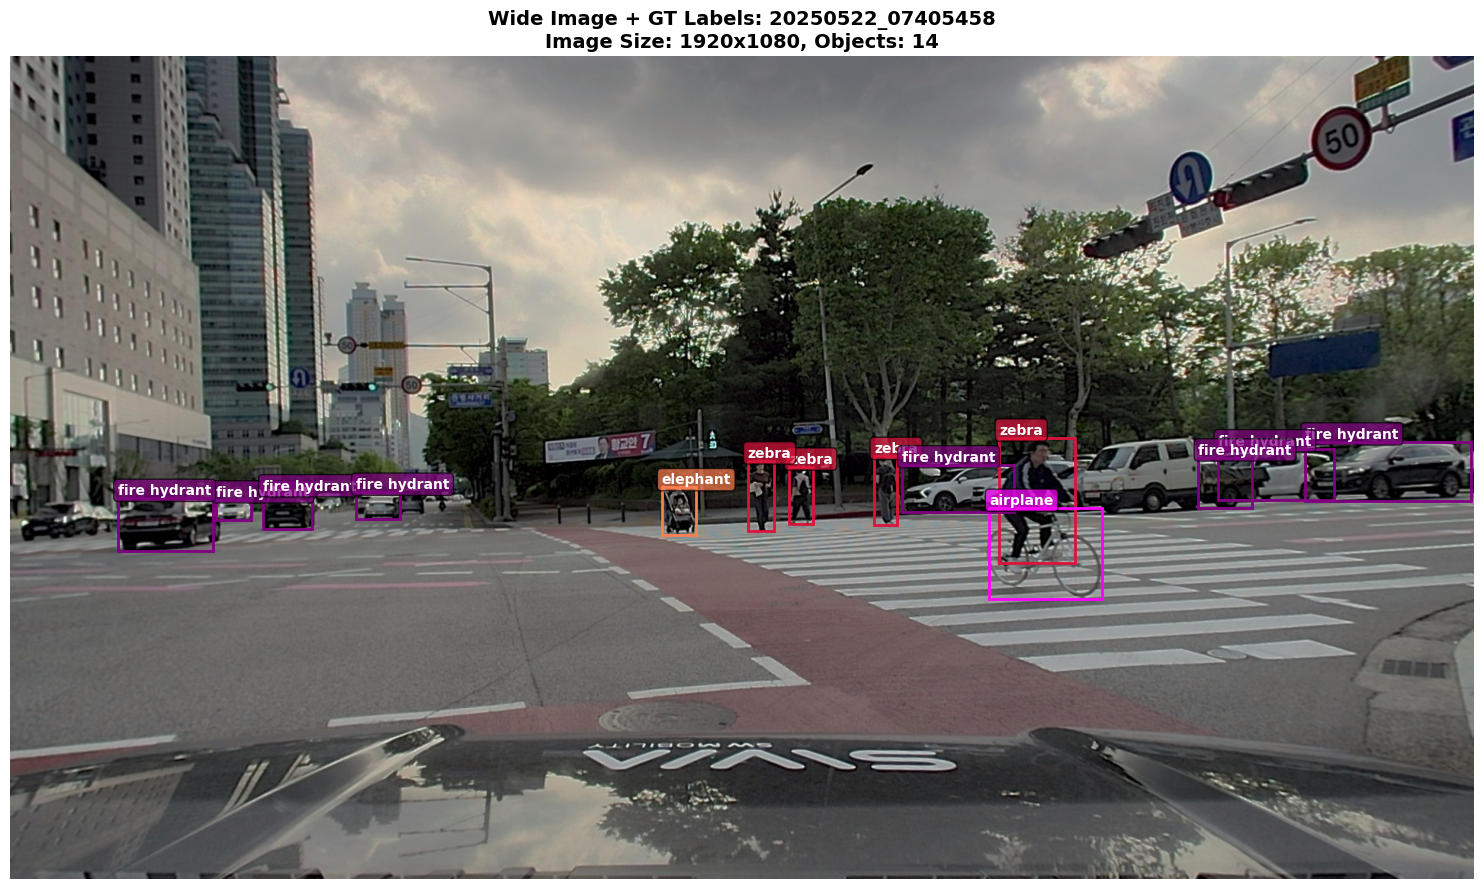


📊 클래스별 객체 수:
  airplane: 1개
  elephant: 1개
  fire hydrant: 8개
  zebra: 4개


In [10]:
# 🖼️ Wide 이미지 + GT Labels 시각화
if file_status['wide']:
    # Wide 이미지 로드
    wide_image = cv2.imread(file_status['wide_path'])
    wide_image_rgb = cv2.cvtColor(wide_image, cv2.COLOR_BGR2RGB)
    height, width = wide_image_rgb.shape[:2]
    
    # GT 라벨 로드
    gt_boxes = load_yolo_labels(file_status['label_path'], width, height)
    
    # 시각화
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    ax.imshow(wide_image_rgb)
    ax.set_title(f"Wide Image + GT Labels: {IMAGE_NAME}\nImage Size: {width}x{height}, Objects: {len(gt_boxes)}", fontsize=14, fontweight='bold')
    
    # GT 박스 그리기
    for i, (class_id, x1, y1, x2, y2) in enumerate(gt_boxes):
        # 박스 색상
        color = COLORS[class_id % len(COLORS)]
        
        # 박스 그리기
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                               linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # 클래스 라벨
        class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
        ax.text(x1, y1-5, f"{class_name}", 
               bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7),
               fontsize=10, color='white', fontweight='bold')
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 통계 정보
    if gt_boxes:
        class_counts = {}
        for class_id, _, _, _, _ in gt_boxes:
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        print(f"\n📊 클래스별 객체 수:")
        for class_name, count in sorted(class_counts.items()):
            print(f"  {class_name}: {count}개")
    else:
        print(f"\n📊 검출된 객체가 없습니다.")
        
else:
    print("❌ Wide 이미지를 로드할 수 없습니다.")


In [ ]:
# 🔍 Narrow 이미지 시각화
if file_status['narrow']:
    # Narrow 이미지 로드
    narrow_image = cv2.imread(file_status['narrow_path'])
    narrow_image_rgb = cv2.cvtColor(narrow_image, cv2.COLOR_BGR2RGB)
    narrow_height, narrow_width = narrow_image_rgb.shape[:2]
    
    # 시각화
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(narrow_image_rgb)
    ax.set_title(f"Narrow Image: {IMAGE_NAME}\nImage Size: {narrow_width}x{narrow_height}", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Narrow 이미지를 로드할 수 없습니다.")


In [ ]:
# 🎲 랜덤 이미지 선택 및 시각화
if image_files:
    # 랜덤하게 이미지 선택
    random_image_name = random.choice(image_files)
    random_file_status = check_files_exist(random_image_name)
    
    print(f"🎲 랜덤 선택된 이미지: {random_image_name}")
    print(f"   Wide: {'✅' if random_file_status['wide'] else '❌'}")
    print(f"   Narrow: {'✅' if random_file_status['narrow'] else '❌'}")
    print(f"   Label: {'✅' if random_file_status['label'] else '❌'}")
    
    if random_file_status['wide'] and random_file_status['narrow']:
        # 이미지들 로드
        wide_img = cv2.imread(random_file_status['wide_path'])
        wide_img_rgb = cv2.cvtColor(wide_img, cv2.COLOR_BGR2RGB)
        wide_h, wide_w = wide_img_rgb.shape[:2]
        
        narrow_img = cv2.imread(random_file_status['narrow_path'])
        narrow_img_rgb = cv2.cvtColor(narrow_img, cv2.COLOR_BGR2RGB)
        narrow_h, narrow_w = narrow_img_rgb.shape[:2]
        
        # GT 라벨 로드
        gt_boxes = load_yolo_labels(random_file_status['label_path'], wide_w, wide_h)
        
        # 3개 서브플롯으로 시각화
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))
        
        # 1. Wide 이미지 + GT Labels
        axes[0].imshow(wide_img_rgb)
        axes[0].set_title(f"Wide + GT Labels\n{wide_w}x{wide_h}, Objects: {len(gt_boxes)}", fontsize=12, fontweight='bold')
        
        # GT 박스 그리기
        for class_id, x1, y1, x2, y2 in gt_boxes:
            color = COLORS[class_id % len(COLORS)]
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                   linewidth=2, edgecolor=color, facecolor='none')
            axes[0].add_patch(rect)
            
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
            axes[0].text(x1, y1-5, f"{class_name}", 
                        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7),
                        fontsize=8, color='white', fontweight='bold')
        
        axes[0].axis('off')
        
        # 2. Wide 이미지 (원본)
        axes[1].imshow(wide_img_rgb)
        axes[1].set_title(f"Wide Image (Original)\n{wide_w}x{wide_h}", fontsize=12, fontweight='bold')
        axes[1].axis('off')
        
        # 3. Narrow 이미지
        axes[2].imshow(narrow_img_rgb)
        axes[2].set_title(f"Narrow Image\n{narrow_w}x{narrow_h}", fontsize=12, fontweight='bold')
        axes[2].axis('off')
        
        plt.suptitle(f"🎲 Random Sample: {random_image_name}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 클래스 통계
        if gt_boxes:
            class_counts = {}
            for class_id, _, _, _, _ in gt_boxes:
                class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
                class_counts[class_name] = class_counts.get(class_name, 0) + 1
            
            print(f"\n📊 클래스별 객체 수:")
            for class_name, count in sorted(class_counts.items()):
                print(f"  {class_name}: {count}개")
        else:
            print(f"\n📊 검출된 객체가 없습니다.")
            
    else:
        print("❌ 이미지 파일들을 로드할 수 없습니다.")
        
else:
    print("❌ 데이터셋에서 이미지를 찾을 수 없습니다.")


In [ ]:
# 📋 전체 데이터셋에서 클래스 분포 확인 (샘플링)
print("📊 데이터셋 클래스 분포 분석 (샘플 100개 기준)...")

sample_size = min(100, len(image_files))
sample_images = random.sample(image_files, sample_size)

total_class_counts = {}
total_objects = 0
images_with_objects = 0

for img_name in sample_images:
    file_status = check_files_exist(img_name)
    if file_status['wide'] and file_status['label']:
        # 이미지 크기 가져오기
        img = cv2.imread(file_status['wide_path'])
        if img is not None:
            h, w = img.shape[:2]
            gt_boxes = load_yolo_labels(file_status['label_path'], w, h)
            
            if gt_boxes:
                images_with_objects += 1
                for class_id, _, _, _, _ in gt_boxes:
                    class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
                    total_class_counts[class_name] = total_class_counts.get(class_name, 0) + 1
                    total_objects += 1

print(f"\n📈 분석 결과 (샘플 {sample_size}개 이미지):")
print(f"  객체가 있는 이미지: {images_with_objects}개")
print(f"  총 객체 수: {total_objects}개")
print(f"  평균 객체 수/이미지: {total_objects/max(1, images_with_objects):.1f}개")

if total_class_counts:
    print(f"\n📊 클래스별 분포:")
    sorted_classes = sorted(total_class_counts.items(), key=lambda x: x[1], reverse=True)
    for class_name, count in sorted_classes:
        percentage = (count / total_objects) * 100
        print(f"  {class_name}: {count}개 ({percentage:.1f}%)")
else:
    print("\n📊 샘플에서 객체를 찾을 수 없습니다.")
